# Early Sepsis Onset Prediction

## End-to-End Pipeline Walkthrough

This notebook mirrors `main.py` and walks through every step of the sepsis prediction pipeline with inline explanations and plots.

**Task**: Predict sepsis onset **6 hours before** a physician's recorded diagnosis using ICU patient data from the PhysioNet Sepsis Challenge 2019 dataset.

**Key challenges addressed**:
- Label noise
- Temporal data leakage
- Irregular time-series with high missing-value rates
- Severe class imbalance

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

# Ensure src/ is importable
sys.path.insert(0, os.path.abspath('..'))

RANDOM_STATE = 42
OUTPUT_DIR = '../outputs'
DATA_DIR = '../data/training_setA'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_STATE)
print('Setup complete.')

Setup complete.


---
## Step 1: Load Data

Read all `.psv` patient files from `data/` and concatenate into a single DataFrame. Each file represents one ICU patient stay with hourly readings.

In [2]:
from src.load_data import load_all_patients

df = load_all_patients(DATA_DIR)
df.head(10)


Loading patient files:   0%|          | 0/6972 [00:00<?, ?it/s]


Loading patient files:   0%|          | 1/6972 [00:00<13:32,  8.58it/s]


Loading patient files:   0%|          | 17/6972 [00:00<01:17, 90.04it/s]


Loading patient files:   0%|          | 33/6972 [00:00<00:59, 116.60it/s]


Loading patient files:   1%|          | 49/6972 [00:00<00:52, 131.64it/s]

...


Loading patient files: 100%|█████████▉| 6945/6972 [00:46<00:00, 169.57it/s]


Loading patient files: 100%|█████████▉| 6969/6972 [00:46<00:00, 185.31it/s]


Loading patient files: 100%|██████████| 6972/6972 [00:46<00:00, 150.85it/s]


  Dataset loaded successfully
  Patients        : 6,972
  Total rows      : 270,132
  SepsisLabel = 1 : 5,766  (2.13%)
  SepsisLabel = 0 : 264,366  (97.87%)
  Columns         : 42



,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001
5,110.0,91.0,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,6,0,p000001
6,108.0,92.0,36.11,123.0,77.00,NaN,29.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,7,0,p000001
7,106.0,90.5,NaN,93.0,76.33,NaN,29.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,8,0,p000001
8,104.0,95.0,NaN,133.0,88.33,NaN,26.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,9,0,p000001
9,102.0,91.0,NaN,134.0,87.33,NaN,30.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,10,0,p000001


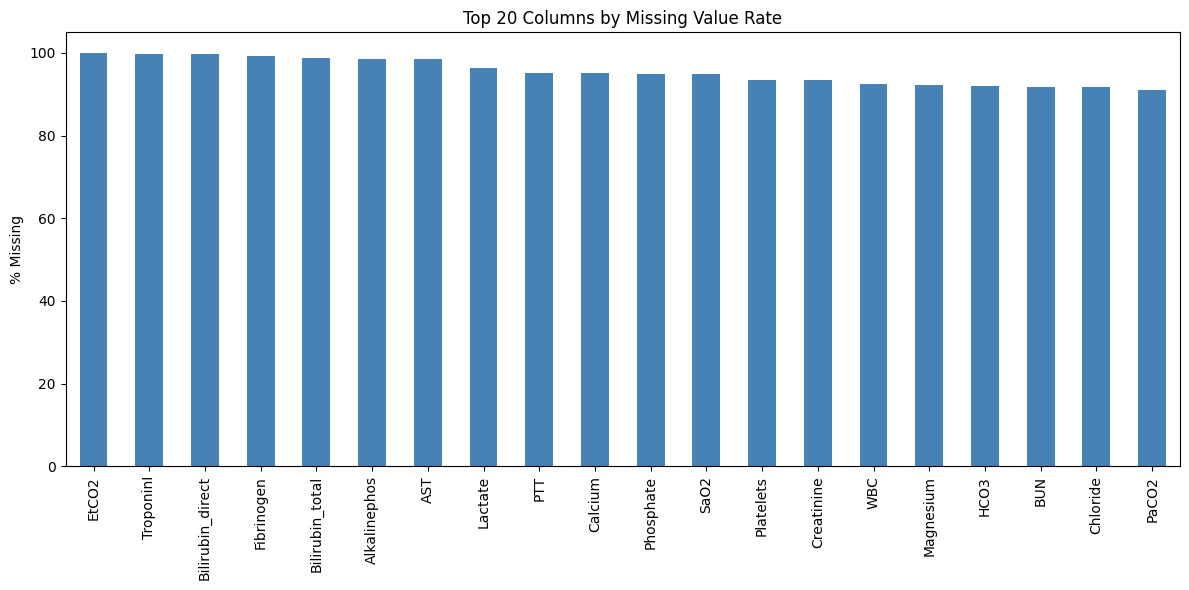

In [3]:
# Quick look at missing-value rates
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
missing_pct.head(20).plot.bar(ax=ax, color='steelblue')
ax.set_ylabel('% Missing')
ax.set_title('Top 20 Columns by Missing Value Rate')
plt.tight_layout()
plt.show()

---
## Step 2: Label Engineering

Create the **6-hour-ahead prediction label** (`label_6h`):
- For each patient, find T = first hour where `SepsisLabel == 1`
- `label_6h = 1` for hours T-6 through T-1
- `label_6h = 0` for all hours before T-6
- **Drop** all rows at T and after (no post-diagnosis data)
- Non-sepsis patients: `label_6h = 0` everywhere

In [4]:
from src.label_engineering import create_6h_labels, patient_level_split

df = create_6h_labels(df)


[Label Engineering] label_6h created
  Positive (1) : 3,052  (1.15%)
  Negative (0) : 261,314  (98.85%)
  Total rows   : 264,366
  Patients     : 6,911



---
## Step 3: Patient-Level Train/Test Split

**Critical**: We split at the patient level so no patient appears in both sets. This prevents temporal data leakage.

In [5]:
df_train, df_test = patient_level_split(df, test_size=0.2, random_state=RANDOM_STATE)

[Split] Patient-level 80/20 split (random_state=42)
  Train patients : 5,528  |  rows : 211,718
  Test  patients : 1,383  |  rows : 52,648
  [OK] No patient overlap between train and test.



---
## Step 4: Feature Engineering

Compute **backward-looking** temporal features:
- Rolling mean, std, min, max (window=6 hours) for key vitals/labs
- Time-since-last-observation for sparse lab values
- ICULOS (ICU length of stay) as a direct feature

All rolling computations use `.shift(1)` to exclude the current hour.

In [6]:
from src.features import engineer_features

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

[Features] Computing rolling statistics (window=6, backward-only) ...



Rolling features:   0%|          | 0/5528 [00:00<?, ?it/s]


Rolling features:   0%|          | 5/5528 [00:00<02:11, 42.07it/s]


Rolling features:   0%|          | 10/5528 [00:00<02:08, 43.05it/s]


Rolling features:   0%|          | 15/5528 [00:00<02:05, 43.78it/s]

...


Time-since features:  86%|████████▌ | 1191/1383 [00:01<00:00, 736.20it/s]


Time-since features:  92%|█████████▏| 1267/1383 [00:01<00:00, 735.76it/s]


Time-since features:  97%|█████████▋| 1342/1383 [00:01<00:00, 708.85it/s]


Time-since features: 100%|██████████| 1383/1383 [00:01<00:00, 808.10it/s]

[Features] Done. Added 28 new temporal features.



---
## Step 5: Preprocessing

1. Add binary **missingness indicators** (before imputation)
2. **Forward-fill** per patient (simulate real-time data availability)
3. **Median imputation** using training-set medians
4. **StandardScaler** normalization (fit on train only)

⚠️ The scaler is fit **only** on training data and then applied to test data.

In [7]:
from src.preprocessing import preprocess

df_train, df_test, scaler, feature_cols = preprocess(df_train, df_test, label_col='label_6h')
print(f'Feature columns: {len(feature_cols)}')

[Preprocessing] Adding missingness indicators ...


[Preprocessing] Forward-filling per patient ...


[Preprocessing] Computing training-set medians & filling ...


[Preprocessing] Fitting scaler on training data ...


[Preprocessing] Done. Feature count: 102
Feature columns: 102


---
## Step 6: Label Noise Detection (cleanlab)

Use cleanlab's `CleanLearning` with a `RandomForestClassifier` to identify and remove likely mislabelled samples from the **training set only**.

In [8]:
from src.label_noise import clean_training_data

df_train_clean, n_removed = clean_training_data(
    df_train, feature_cols, label_col='label_6h', random_state=RANDOM_STATE
)

# Prepare arrays
X_train = df_train_clean[feature_cols].values
y_train = df_train_clean['label_6h'].values.astype(int)
X_test = df_test[feature_cols].values
y_test = df_test['label_6h'].values.astype(int)

print(f'Final training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

[Label Noise] Running cleanlab noise detection ...


[Label Noise] Detected 149 noisy samples (0.07%)
[Label Noise] Keeping 211,569 clean samples.



Final training set: (211569, 102)
Test set: (52648, 102)


---
## Step 7: Model Training & Calibration

### 7a. XGBoost (Baseline)
- `scale_pos_weight` handles class imbalance
- Early stopping on a 15% validation hold-out

In [9]:
from src.model import train_xgboost, train_lightgbm
from src.calibration import calibrate_model, get_calibrated_predictions

xgb_model = train_xgboost(X_train, y_train, random_state=RANDOM_STATE, output_dir=OUTPUT_DIR)

[Model] Training XGBoost baseline ...
  scale_pos_weight = 88.99


  Best iteration: 499
  Saved to ../outputs\xgboost_model.joblib



In [10]:
print('Calibrating XGBoost ...')
xgb_model.set_params(early_stopping_rounds=None)
xgb_calibrated = calibrate_model(xgb_model, X_train, y_train)
xgb_probs = get_calibrated_predictions(xgb_calibrated, X_test)
print('Done.')

Calibrating XGBoost ...


Done.


### 7b. LightGBM (Advanced)

In [11]:
lgbm_model = train_lightgbm(X_train, y_train, random_state=RANDOM_STATE, output_dir=OUTPUT_DIR)

[Model] Training LightGBM advanced model ...
  scale_pos_weight = 88.99


  Best iteration: 500
  Saved to ../outputs\lightgbm_model.joblib



In [12]:
print('Calibrating LightGBM ...')
lgbm_calibrated = calibrate_model(lgbm_model, X_train, y_train)
lgbm_probs = get_calibrated_predictions(lgbm_calibrated, X_test)
print('Done.')

Calibrating LightGBM ...


Done.


---
## Step 8: Evaluation

For both models we compute:
- **Confusion matrix** (saved as PNG)
- **Classification report** (precision, recall, F1)
- **AUROC** and **AUPRC** (AUPRC is more informative for imbalanced data)
- **Calibration curve** (both models on one plot)
- **Threshold analysis** at 0.3, 0.4, 0.5, 0.6

In [13]:
from src.evaluate import evaluate_all

prob_dict = {
    'XGBoost': xgb_probs,
    'LightGBM': lgbm_probs,
}

results = evaluate_all(y_test, prob_dict, output_dir=OUTPUT_DIR)


  Evaluation — XGBoost
  AUROC  : 0.7410
  AUPRC  : 0.0450

  Classification Report (threshold=0.5):
              precision    recall  f1-score   support

   No Sepsis       0.99      1.00      0.99     52052
      Sepsis       0.00      0.00      0.00       596

    accuracy                           0.99     52648
   macro avg       0.49      0.50      0.50     52648
weighted avg       0.98      0.99      0.98     52648



  Saved confusion matrix -> ../outputs\confusion_matrix_xgboost.png

  Threshold Analysis — XGBoost
   Threshold  Precision     Recall         F1
  --------------------------------------------
        0.30     0.0000     0.0000     0.0000
        0.40     0.0000     0.0000     0.0000
        0.50     0.0000     0.0000     0.0000
        0.60     0.0000     0.0000     0.0000


  Evaluation — LightGBM
  AUROC  : 0.7299
  AUPRC  : 0.0434

  Classification Report (threshold=0.5):
              precision    recall  f1-score   support

   No Sepsis       0.99      1.00      0.99     52052
      Sepsis       0.00      0.00      0.00       596

    accuracy                           0.99     52648
   macro avg       0.49      0.50      0.50     52648
weighted avg       0.98      0.99      0.98     52648



  Saved confusion matrix -> ../outputs\confusion_matrix_lightgbm.png

  Threshold Analysis — LightGBM
   Threshold  Precision     Recall         F1
  --------------------------------------------
        0.30     0.0000     0.0000     0.0000
        0.40     0.0000     0.0000     0.0000
        0.50     0.0000     0.0000     0.0000
        0.60     0.0000     0.0000     0.0000



  Saved calibration curve -> ../outputs\calibration_curve.png


### Confusion Matrices


XGBOOST Confusion Matrix:


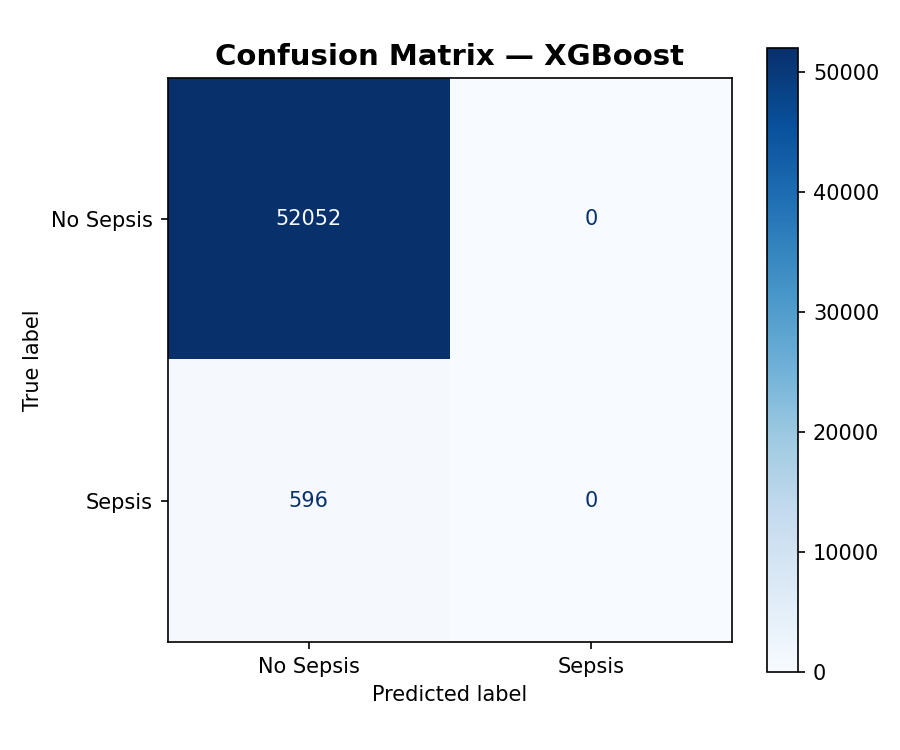


LIGHTGBM Confusion Matrix:


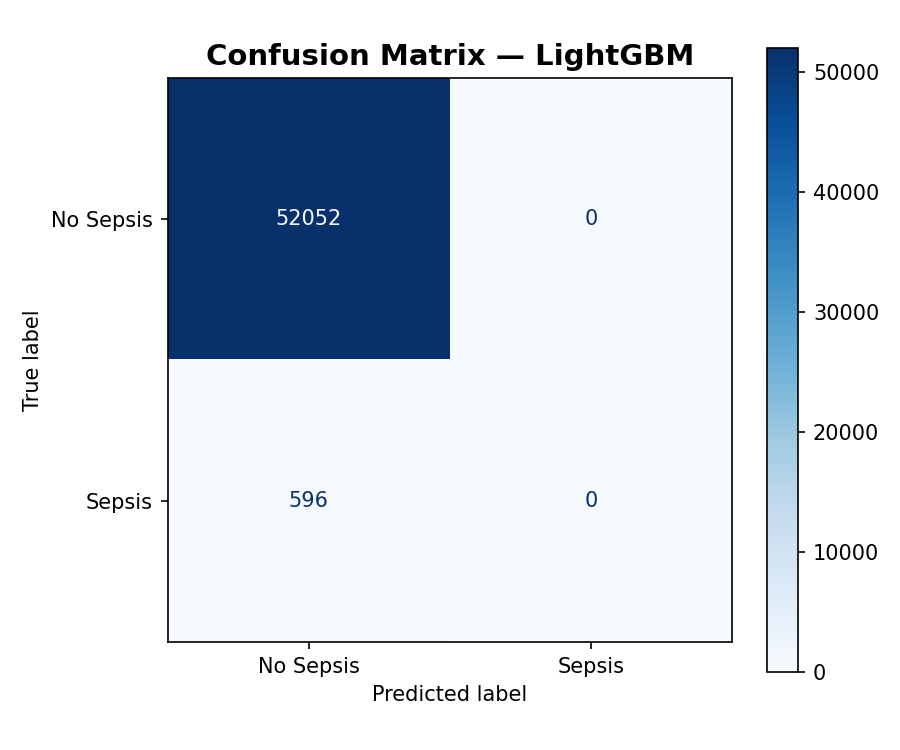

In [14]:
from IPython.display import Image, display

for name in ['xgboost', 'lightgbm']:
    path = os.path.join(OUTPUT_DIR, f'confusion_matrix_{name}.png')
    if os.path.exists(path):
        print(f'\n{name.upper()} Confusion Matrix:')
        display(Image(filename=path))

### Calibration Curve

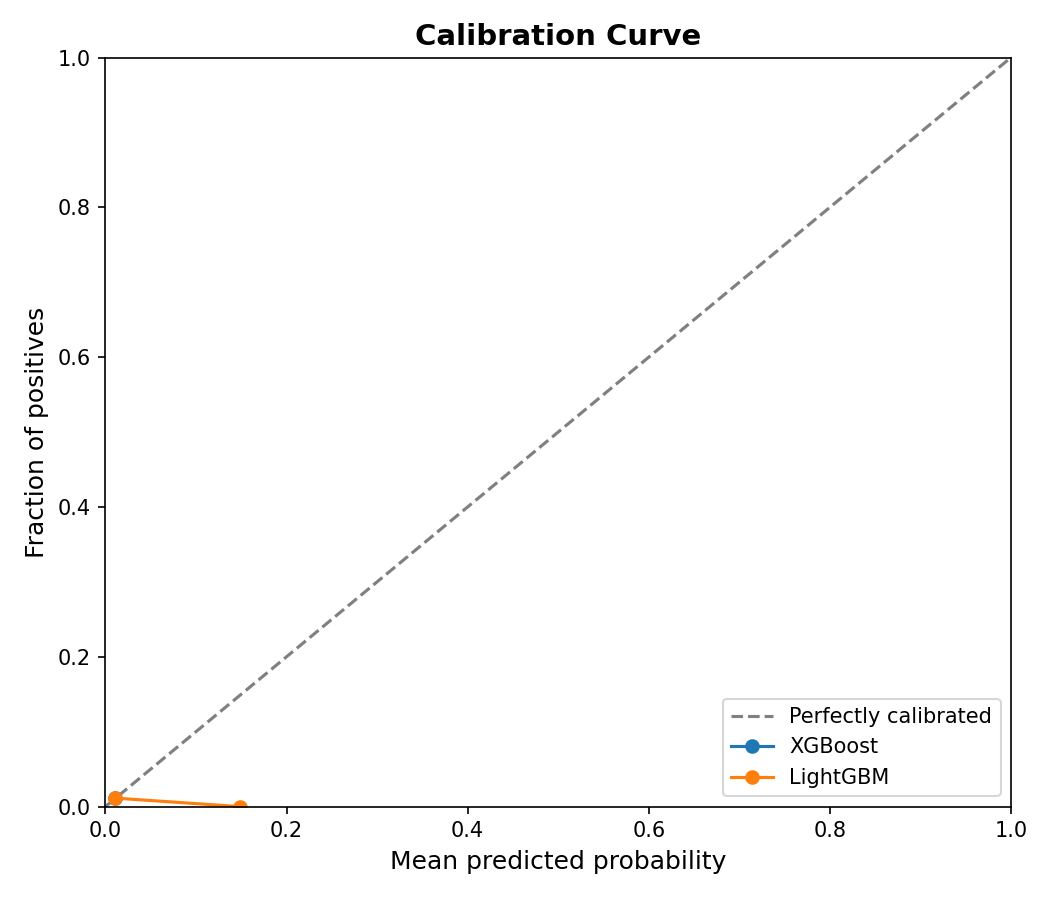

In [15]:
cal_path = os.path.join(OUTPUT_DIR, 'calibration_curve.png')
if os.path.exists(cal_path):
    display(Image(filename=cal_path))

---
## Summary

| Metric | XGBoost | LightGBM |
|--------|---------|----------|
| AUROC  | See above | See above |
| AUPRC  | See above | See above |

**Key takeaways**:
- AUPRC is the more informative metric for this highly imbalanced task.
- Calibration curves show whether predicted probabilities match observed frequencies.
- The threshold analysis helps clinicians choose an operating point that balances sensitivity and specificity.
- Label noise removal with cleanlab improved training data quality.

Results and plots are saved in the `outputs/` directory.